# 05 — Results and Discussion

Read-only synthesis of notebooks 01–04. This notebook does **not** retrain the final models — it consumes the saved prediction CSVs, classifier benchmark table, and model outputs to produce the headline tables, plots, and discussion that the project report draws from.

**Pipeline recap:**
1. **01_data_loading** — clean RECS 2020 (18,495 households × 69 cols), derive end-use $ columns, define `efficiency_class` as climate-stratified tertile of `cost_per_sqft`.
2. **02_eda** — weighted distribution / correlation analysis; confirmed size proxies dominate `TOTALDOL` and validated per-sqft normalization.
3. **03_classification** — Multinomial Logistic Regression on `efficiency_class`, plus a quick nonlinear classifier benchmark.
4. **04_regression** — Elastic Net baseline and Gradient Boosting Regressor on `TOTALDOL`.


## Setup

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, mean_squared_error, r2_score,
                             mean_absolute_error)

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_DIR   = '../data'
MODELS_DIR = '../models'


In [2]:
def load_clean_recs(data_dir):
    parquet_path = os.path.join(data_dir, 'recs2020_clean.parquet')
    pickle_path = os.path.join(data_dir, 'recs2020_clean.pkl')
    if os.path.exists(parquet_path):
        return pd.read_parquet(parquet_path)
    return pd.read_pickle(pickle_path)

df       = load_clean_recs(DATA_DIR)
split    = json.load(open(os.path.join(DATA_DIR, 'train_test_split.json')))
clf_pred = pd.read_csv(os.path.join(MODELS_DIR, 'logreg_test_predictions.csv'))
reg_pred = pd.read_csv(os.path.join(MODELS_DIR, 'regression_test_predictions.csv'))
bench_path = os.path.join(MODELS_DIR, 'classifier_benchmark.csv')
classifier_benchmark = pd.read_csv(bench_path) if os.path.exists(bench_path) else pd.DataFrame()

print('df       :', df.shape)
print('clf_pred :', clf_pred.shape)
print('reg_pred :', reg_pred.shape)
print('benchmark:', classifier_benchmark.shape)


df       : (18495, 69)
clf_pred : (3699, 8)
reg_pred : (3699, 6)
benchmark: (4, 5)


## Classification — predicting `efficiency_class`

Three balanced classes within each climate group (efficient / average / inefficient). Random-baseline accuracy is about 33.3%. The report model uses 55 features, about 216 after one-hot encoding, and weighted evaluation so the result represents U.S. households rather than raw survey rows.


In [3]:
y_true = clf_pred['true']
y_pred = clf_pred['pred']
w      = clf_pred['NWEIGHT']
labels = ['efficient', 'average', 'inefficient']

acc = accuracy_score(y_true, y_pred, sample_weight=w)
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, sample_weight=w, zero_division=0)

overall = pd.DataFrame({
    'class':     labels,
    'precision': prec,
    'recall':    rec,
    'f1':        f1,
    'support':   support,
})
print(f"Weighted overall accuracy: {acc:.3f}")
print(f"(random baseline ≈ 0.333 — three balanced classes)")
print()
print(overall.to_string(index=False))


Weighted overall accuracy: 0.604
(random baseline ≈ 0.333 — three balanced classes)

      class  precision  recall    f1       support
  efficient      0.656   0.641 0.649 7,834,464.491
    average      0.493   0.438 0.464 8,446,143.240
inefficient      0.648   0.731 0.687 8,828,617.692


## Classifier model choice

Logistic Regression is the report classifier because it gives a coefficient-based explanation of which home characteristics push a prediction toward `efficient` or `inefficient`. The quick benchmark below is included so the model choice is transparent: Gradient Boosting is the stronger accuracy-first candidate, while Logistic Regression is the clearer explanatory model.


In [4]:
if classifier_benchmark.empty:
    print('classifier_benchmark.csv not found; rerun notebook 03 to regenerate it.')
else:
    display(classifier_benchmark)


,Classifier,Weighted accuracy,Weighted F1,Fit seconds,Role
0,Dummy majority,0.352,0.183,0.000,naive baseline
1,Logistic Regression,0.604,0.600,NaN,final interpretable report model
2,Random Forest quick check,0.582,0.575,0.600,"nonlinear comparison, worse"
3,Gradient Boosting Classifier quick check,0.621,0.620,28.300,best quick accuracy check; promote if optimizi...


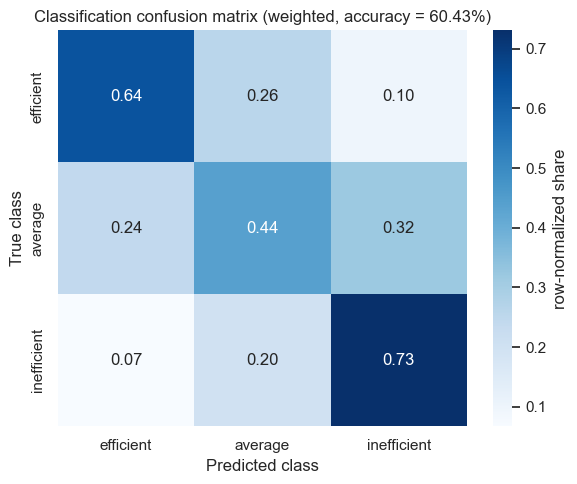

In [5]:
# Confusion matrix (weighted) as a heatmap
cm = confusion_matrix(y_true, y_pred, labels=labels, sample_weight=w)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=cm_norm, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'row-normalized share'}, ax=ax)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title(f'Classification confusion matrix (weighted, accuracy = {acc:.2%})')
plt.tight_layout()
plt.show()


                weighted_accuracy  n_test
BA_climate_grp                           
Hot-Humid                   0.549     510
Marine                      0.597     183
Hot-Dry                     0.599     315
Cold                        0.620    1422
Mixed-Humid                 0.622    1116
Very-Cold                   0.628     125
Mixed-Dry                   0.663      28


/var/folders/07/d949z7_509s8tfzn2f_q63wc0000gn/T/ipykernel_24452/2126000821.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: accuracy_score(g['true'], g['pred'],


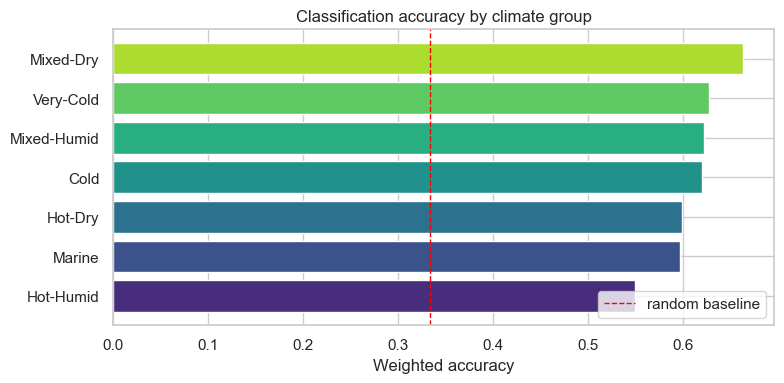

In [6]:
# Per-climate accuracy
per_clim = (clf_pred.groupby('BA_climate_grp', observed=True)
                    .apply(lambda g: accuracy_score(g['true'], g['pred'],
                                                    sample_weight=g['NWEIGHT']))
                    .rename('weighted_accuracy')
                    .to_frame()
                    .join(clf_pred.groupby('BA_climate_grp', observed=True)
                                  .size().rename('n_test')))
per_clim = per_clim.sort_values('weighted_accuracy', ascending=True)
print(per_clim)

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('viridis', n_colors=len(per_clim))
ax.barh(per_clim.index, per_clim['weighted_accuracy'], color=colors)
ax.axvline(1/3, color='red', linestyle='--', linewidth=1, label='random baseline')
ax.set_xlabel('Weighted accuracy')
ax.set_title('Classification accuracy by climate group')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Regression — predicting `TOTALDOL`

We compare two models head-to-head on the same held-out test set:

- **Mean baseline** — predicts the weighted training mean; this is the naive reference point.
- **Elastic Net** — combined L1/L2 regularization, linear, fast, and interpretable.
- **Gradient Boosting** — captures nonlinear interactions but is more expensive.

All metrics are weighted by `NWEIGHT`.


In [7]:
def reg_metrics(y, y_pred, w):
    rmse = float(np.sqrt(mean_squared_error(y, y_pred, sample_weight=w)))
    mae  = float(mean_absolute_error(y, y_pred, sample_weight=w))
    r2   = float(r2_score(y, y_pred, sample_weight=w))
    bias = float(np.average(y_pred - y, weights=w))
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'mean_bias': bias}

y     = reg_pred['TOTALDOL_true']
w_reg = reg_pred['NWEIGHT']
train_doeid = set(split['train_doeid'])
train_df = df[df['DOEID'].isin(train_doeid)]
weighted_train_mean = float(np.average(train_df['TOTALDOL'], weights=train_df['NWEIGHT']))
mean_baseline = np.full(len(y), weighted_train_mean)

metric_table = pd.DataFrame({
    'Mean baseline':      reg_metrics(y, mean_baseline, w_reg),
    'Elastic Net':        reg_metrics(y, reg_pred['pred_enet'], w_reg),
    'Gradient Boosting':  reg_metrics(y, reg_pred['pred_gbr'],  w_reg),
}).T
print(metric_table)


                       RMSE     MAE     R2  mean_bias
Mean baseline     1,062.990 762.393 -0.000      6.144
Elastic Net         751.905 504.761  0.500      0.203
Gradient Boosting   744.836 493.856  0.509     -3.042


                Elastic Net  Gradient Boosting
BA_climate_grp                                
Marine              551.972            543.354
Mixed-Humid         743.373            710.249
Hot-Humid           711.592            728.115
Hot-Dry             760.160            769.855
Cold                781.309            781.759
Very-Cold           958.285            845.340
Mixed-Dry         1,321.927          1,319.456


/var/folders/07/d949z7_509s8tfzn2f_q63wc0000gn/T/ipykernel_24452/340453249.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.sqrt(mean_squared_error(
/var/folders/07/d949z7_509s8tfzn2f_q63wc0000gn/T/ipykernel_24452/340453249.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.sqrt(mean_squared_error(


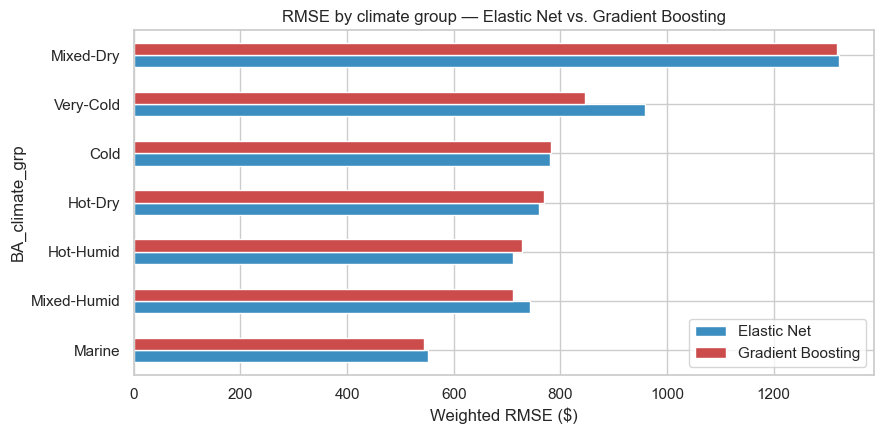

In [8]:
# Per-climate RMSE comparison
def per_climate_rmse(col):
    return (reg_pred.groupby('BA_climate_grp', observed=True)
            .apply(lambda g: float(np.sqrt(mean_squared_error(
                g['TOTALDOL_true'], g[col], sample_weight=g['NWEIGHT']))))
            .rename(col))

clim_rmse = pd.concat([per_climate_rmse('pred_enet'),
                       per_climate_rmse('pred_gbr')], axis=1)
clim_rmse.columns = ['Elastic Net', 'Gradient Boosting']
clim_rmse = clim_rmse.sort_values('Gradient Boosting', ascending=True)
print(clim_rmse)

fig, ax = plt.subplots(figsize=(9, 4.5))
clim_rmse.plot(kind='barh', ax=ax, color=['#3c8ec0', '#cc4c4c'])
ax.set_xlabel('Weighted RMSE ($)')
ax.set_title('RMSE by climate group — Elastic Net vs. Gradient Boosting')
plt.tight_layout()
plt.show()


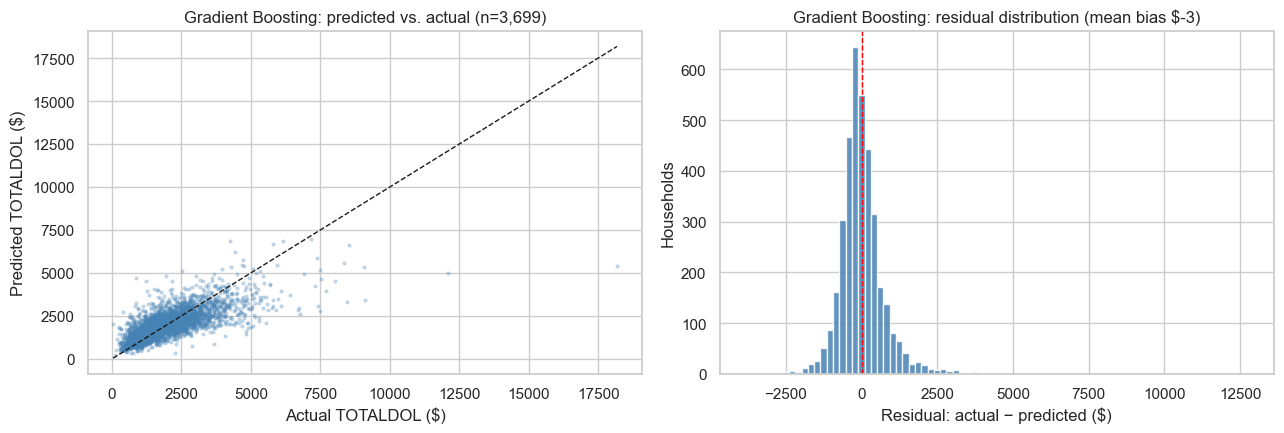

In [9]:
# Diagnostic plot for the better model
better = ('Gradient Boosting' if metric_table.loc['Gradient Boosting', 'RMSE']
          < metric_table.loc['Elastic Net', 'RMSE'] else 'Elastic Net')
pred_col = 'pred_gbr' if better == 'Gradient Boosting' else 'pred_enet'
y_pred = reg_pred[pred_col]
resid  = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y, y_pred, s=4, alpha=0.25, color='steelblue')
mn, mx = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
axes[0].set_xlabel('Actual TOTALDOL ($)')
axes[0].set_ylabel('Predicted TOTALDOL ($)')
axes[0].set_title(f'{better}: predicted vs. actual (n={len(y):,})')

axes[1].hist(resid, bins=80, color='steelblue', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual: actual − predicted ($)')
axes[1].set_ylabel('Households')
axes[1].set_title(f'{better}: residual distribution (mean bias '
                  f'${metric_table.loc[better, "mean_bias"]:,.0f})')
plt.tight_layout()
plt.show()


## Regression outliers and limitations

The aggregate RMSE is useful, but the largest errors matter because utility bills are right-skewed. These are the households where the model underpredicts or overpredicts most severely.


In [10]:
outlier_view = reg_pred.merge(
    df[['DOEID', 'TOTSQFT_EN', 'cost_per_sqft']],
    on='DOEID',
    how='left',
)
outlier_view['residual_gbr'] = outlier_view['TOTALDOL_true'] - outlier_view['pred_gbr']
outlier_view['abs_residual_gbr'] = outlier_view['residual_gbr'].abs()
outlier_view = outlier_view.sort_values('abs_residual_gbr', ascending=False)
outlier_view[['DOEID', 'BA_climate_grp', 'TOTSQFT_EN', 'cost_per_sqft', 'TOTALDOL_true', 'pred_gbr', 'residual_gbr']].head(10)


,DOEID,BA_climate_grp,TOTSQFT_EN,cost_per_sqft,TOTALDOL_true,pred_gbr,residual_gbr
1654,108344,Cold,15000,1.212,"18,176.890","5,387.085","12,789.805"
1326,106662,Hot-Humid,4670,2.588,"12,084.840","4,978.958","7,105.882"
2129,110722,Hot-Humid,4400,2.067,"9,093.350","3,443.652","5,649.698"
2654,113203,Mixed-Humid,1010,8.385,"8,469.310","3,300.529","5,168.781"
3693,118456,Mixed-Dry,2000,3.742,"7,484.770","2,766.607","4,718.163"
1019,105205,Cold,3400,2.177,"7,402.640","3,100.988","4,301.652"
2559,112726,Hot-Humid,2500,2.710,"6,773.920","2,613.781","4,160.139"
1033,105251,Hot-Dry,6100,0.142,867.020,"4,720.603","-3,853.583"
535,102960,Cold,1200,5.563,"6,675.730","2,858.693","3,817.037"
2571,112755,Cold,3150,2.137,"6,731.270","2,947.572","3,783.698"


## Cross-cutting analysis — do the two layers tell a coherent story?

The classifier sorts households into `efficiency_class` tertiles (defined on cost-per-sqft within climate). The regressor predicts total annual dollars. These two views are **not** identical — a small drafty home can be classified inefficient while still having a low absolute bill. We check the alignment empirically.

In [11]:
joined = clf_pred.merge(reg_pred[['DOEID','pred_gbr','TOTALDOL_true']], on='DOEID')

ct = (joined.groupby('pred', observed=True)
            .agg(n=('DOEID','count'),
                 mean_pred_dol=('pred_gbr','mean'),
                 mean_true_dol=('TOTALDOL_true','mean'))
            .reindex(['efficient','average','inefficient']))
print(ct)


                n  mean_pred_dol  mean_true_dol
pred                                           
efficient    1203      2,018.146      1,981.036
average      1154      2,059.687      2,072.080
inefficient  1342      1,928.298      1,948.938


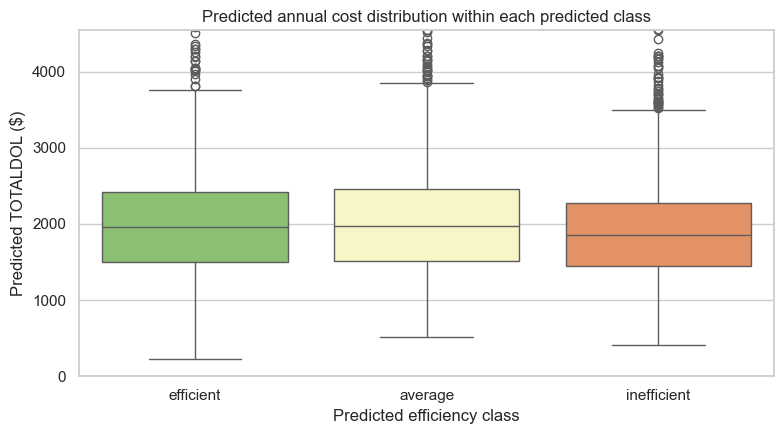

In [12]:
# Visualize the relationship: predicted-class boxplot of predicted TOTALDOL
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=joined, x='pred', y='pred_gbr',
            order=['efficient','average','inefficient'],
            hue='pred', palette='RdYlGn_r', legend=False, ax=ax)
ax.set_ylim(0, joined['pred_gbr'].quantile(0.99))
ax.set_xlabel('Predicted efficiency class')
ax.set_ylabel('Predicted TOTALDOL ($)')
ax.set_title('Predicted annual cost distribution within each predicted class')
plt.tight_layout()
plt.show()


In [13]:
# Walk-through: highest-bill test household
focus_id = joined.sort_values('TOTALDOL_true', ascending=False)['DOEID'].iloc[0]
focus_meta = joined[joined['DOEID'] == focus_id].iloc[0]
print(f"DOEID {focus_id}")
print(f"  climate           : {focus_meta['BA_climate_grp']}")
print(f"  true class        : {focus_meta['true']}")
print(f"  predicted class   : {focus_meta['pred']}")
print(f"  actual TOTALDOL   : ${focus_meta['TOTALDOL_true']:,.0f}")
print(f"  predicted TOTALDOL: ${focus_meta['pred_gbr']:,.0f}")


DOEID 108344
  climate           : Cold
  true class        : average
  predicted class   : efficient
  actual TOTALDOL   : $18,177
  predicted TOTALDOL: $5,387


## Conclusion

The Home Energy Copilot pipeline runs end-to-end on RECS 2020 across two modeling layers:

- A **multinomial Logistic Regression classifier** sorts households into efficient / average / inefficient classes within their climate peer group, achieving weighted accuracy around 60% against a roughly 33% naive baseline.
- A quick **Gradient Boosting classifier** benchmark improves classification F1 modestly, so the honest model-choice story is an accuracy-vs-interpretability tradeoff rather than "trees do not help." Logistic Regression remains the report model because its coefficients are easier to defend and explain.
- A **Gradient Boosting Regressor** estimates annual energy spend with weighted RMSE around $745 and R² around 0.51, outperforming the weighted mean baseline and slightly improving over Elastic Net.

**The two views are complementary, not redundant.** Classification answers *"how does this home compare to its climate peers in cost per square foot?"*; regression answers *"what absolute dollar amount should this household expect?"*. The cross-cutting analysis confirms these are different signals: a household can be inefficient for its size and climate while still having a modest total bill, and a large home can have a high bill while still being efficient per square foot.

**What we did not do:** we did not keep SVR because it scales poorly after one-hot encoding, did not use neural networks because the dataset is tabular and explanation-focused, and did not build a recommendation/ROI system because RECS does not contain intervention costs or causal savings labels.

**Main limitations:** results reflect 2020 survey behavior, many features are self-reported, Logistic Regression leaves some nonlinear classification performance on the table, and high-bill outliers still dominate regression RMSE. These are the right caveats to carry into the final report and presentation.
